# 1. Preparing Data for CNN Input

- Load preprocessed log-mel spectrograms and labels from `.npy` files.  
- Inspect shapes and dtypes to confirm the data matches expectations.  
- Add a channel dimension and cast spectrograms to `float32` so they are ready for Keras/TensorFlow.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
X_train = np.load("X_train.npy")
X_test  = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_test  = np.load("y_test.npy")

In [ ]:
# 1) Add channel dimension
X_train = X_train[..., np.newaxis]
X_test  = X_test[...,  np.newaxis]

# 2) Cast spectrograms to float32
X_train = X_train.astype("float32")
X_test  = X_test.astype("float32")

# 2. Encoding Labels

- The genre labels are strings, but the CNN expects integer class indices.  
- We use `LabelEncoder` to map each genre to an integer from 0 to 9.  
- We store the label order so we can interpret predictions later.

In [ ]:
label_encoder = LabelEncoder()

# Fit on training labels and transform both train and test
y_train_int = label_encoder.fit_transform(y_train)
y_test_int  = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)

num_classes = len(label_encoder.classes_)
print("Number of classes:", num_classes)

Classes: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']
y_train_int: (7987,) int64
y_test_int : (1994,) int64
Number of classes: 10


# 3. Defining the CNN Architecture

- Use a compact CNN that takes a single log-mel spectrogram as input.  
- Three convolutional blocks learn time–frequency patterns.  
- A dense classifier head outputs probabilities over 10 genres.  
- Adam optimizer and sparse categorical cross-entropy are used for multi-class classification.

In [ ]:
def build_melspec_cnn(input_shape, num_classes):
 
    #CNN for mel-spectrogram-based music genre classification.
    #input_shape: (height, width, channels)
    #num_classes: number of genre classes.

    model = models.Sequential()

    # Block 1
    model.add(layers.Conv2D(32, (3, 3), padding="same", activation="relu", input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), padding="same", activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 3
    model.add(layers.Conv2D(128, (3, 3), padding="same", activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))

    # Flatten + classifier
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation="softmax"))

    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

input_shape = X_train.shape[1:]   # (H, W, 1)
print("Input shape for CNN:", input_shape)

model = build_melspec_cnn(input_shape, num_classes)
model.summary()

Input shape for CNN: (128, 130, 1)


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-03 15:52:31.632976: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-03-03 15:52:31.633013: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-03-03 15:52:31.633022: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-03-03 15:52:31.633037: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-03 15:52:31.633048: I tensorflow/core/common_runtime/pluggable_device/plu

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 130, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 130, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 65, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289,290 (16.36 MB)

 Trainable params: 4,288,842 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

# 4. Training the CNN (Baseline)

- Train the CNN on the training spectrograms with an 80/20 train–validation split.  
- Use `EarlyStopping` on validation loss with patience of 5 epochs to reduce overfitting.  
- Train for up to 25 epochs with batch size 32; training can stop earlier if validation loss stops improving.

In [6]:
batch_size = 32
epochs = 25

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train_int,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/25


2026-03-03 15:52:32.605213: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


200/200 ━━━━━━━━━━━━━━━━━━━━ 31s 148ms/step - accuracy: 0.3343 - loss: 56.4956 - val_accuracy: 0.3123 - val_loss: 40.0028
Epoch 2/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 31s 154ms/step - accuracy: 0.4642 - loss: 47.5045 - val_accuracy: 0.5945 - val_loss: 26.7133
Epoch 3/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 30s 151ms/step - accuracy: 0.5757 - loss: 31.3563 - val_accuracy: 0.6058 - val_loss: 21.7719
Epoch 4/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 31s 153ms/step - accuracy: 0.6492 - loss: 19.6831 - val_accuracy: 0.4312 - val_loss: 67.9995
Epoch 5/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 31s 153ms/step - accuracy: 0.7042 - loss: 13.0146 - val_accuracy: 0.5889 - val_loss: 19.7894
Epoch 6/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 31s 152ms/step - accuracy: 0.7428 - loss: 9.4659 - val_accuracy: 0.6865 - val_loss: 13.7790
Epoch 7/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 30s 151ms/step - accuracy: 0.7756 - loss: 7.1283 - val_accuracy: 0.5701 - val_loss: 22.8729
Epoch 8/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 30s 151ms/step - accuracy: 0.8128 - loss: 

# 6. Training Performance Visualization

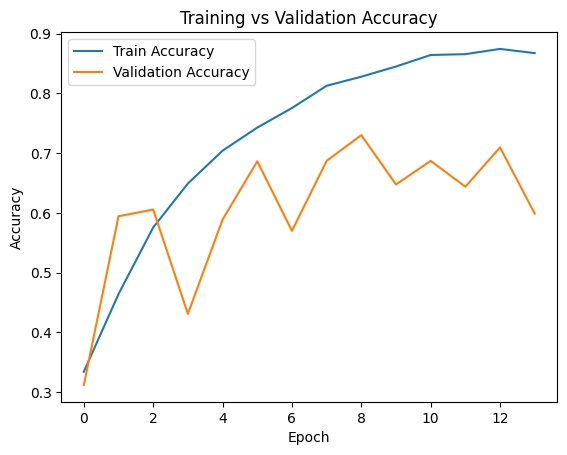

In [7]:
plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# 5. Evaluating the CNN

- Evaluate the final model on the held-out test set.  
- Report test loss and accuracy as the main baseline metrics.  

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test_int, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 8.0319
Test accuracy: 0.7497


In [ ]:
# Predict classes for the test set
y_pred_probs = model.predict(X_test)

# Convert softmax probabilities to class indices
y_pred = y_pred_probs.argmax(axis=1)

print("Classification Report:")
print(classification_report(y_test_int, y_pred, target_names=label_encoder.classes_))

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
Classification Report:
              precision    recall  f1-score   support

       blues       0.57      0.81      0.67       200
   classical       0.83      0.96      0.89       199
     country       0.66      0.58      0.62       198
       disco       0.77      0.73      0.75       200
      hiphop       0.80      0.79      0.79       198
        jazz       0.95      0.57      0.71       200
       metal       0.90      0.84      0.87       200
         pop       0.83      0.69      0.75       200
      reggae       0.92      0.78      0.84       200
        rock       0.53      0.75      0.62       199

    accuracy                           0.75      1994
   macro avg       0.78      0.75      0.75      1994
weighted avg       0.78      0.75      0.75      1994



# 6. Summary and Next Steps

- Built and trained a 3-block CNN on log-mel spectrograms for 10-way genre classification.  
- Achieved a test accuracy of about 0.70 on the GTZAN test split using early stopping.  